# Benchmark Evaluation — Quantum-Inspired Feature Selection on Synthetic Genomic Data
### Master's Thesis Experiments · 8 Regimes × 3 Seeds

---

**Authors:** *ADDAR Seifeddine RABEHI Lokmane*  
**Institution:** *SAAD DAHLEB BLIDA 1*  
**Date:** 2026

---

## Abstract

This notebook implements and benchmarks four feature-selection methods on synthetic genomic data:

| Method | Description |
|--------|-------------|
| **MI-LR** | Mutual-Information filter + Logistic Regression |
| **LASSO** | L1-regularised Logistic Regression (with MI pre-filter) |
| **QUBO-SA** | Quantum-Inspired QUBO solved by Simulated Annealing |
| **FP-Growth** | Frequent-Pattern mining + Logistic Regression |

Each method is evaluated across **8 experimental regimes** (baseline, high-noise, extreme-sparsity, …) and **3 random seeds** using 5-fold stratified cross-validation.

**Primary metrics:** Biomarker Recall, Precision, AUC-ROC, F1-score.

**Known issue fixed in this version:** The original `recall_at_k` function sliced an *unordered* `set`, making top-K recall meaningless. The corrected implementation preserves rank order based on cross-fold vote counts before slicing.

---

## Notebook Structure

1. [Environment Setup](#setup)  
2. [Helper & Metric Functions](#helpers)  
3. [Feature-Selection Method Wrappers](#methods)  
4. [Main Benchmark Loop](#loop)  
5. [Aggregation & CSV Export](#export)  
6. [Visualisation](#viz)  
7. [Conclusions](#conclusions)


## 1. Environment Setup <a id='setup'></a>

Import all required libraries, fix the global random seed, and configure cross-validation.

In [1]:
import gc
import time
import json
import itertools
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, f1_score,
    precision_score, recall_score,
    confusion_matrix,
)
from scipy.optimize import dual_annealing

# ──  FP-Growth ──────────────────────────────────────────────────────
try:
    from mlxtend.frequent_patterns import fpgrowth
    HAS_MLXTEND = True
except ImportError:
    HAS_MLXTEND = False
    warnings.warn("mlxtend not installed — FP-Growth will be skipped.", stacklevel=2)

# ── Reproducibility ─────────────────────────────────────────────────────────
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# ── Cross-validation ─────────────────────────────────────────────────────────
N_SPLITS = 5
SKF = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=GLOBAL_SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR = Path("outputs")

print(f"NumPy  {np.__version__}")
print(f"Pandas {pd.__version__}")
print(f"mlxtend available: {HAS_MLXTEND}")
print(f"Base output dir:   {BASE_DIR.resolve()}")


NumPy  2.4.4
Pandas 3.0.2
mlxtend available: True
Base output dir:   C:\final coding\synthetic_tests\new_exp\outputs


## 2. Helper & Metric Functions <a id='helpers'></a>

### 2.1 Per-fold classification metrics
`compute_fold_metrics` returns a dictionary with accuracy, precision, recall, F1, AUC-ROC, sensitivity, and specificity for a single fold.

### 2.2 Cross-validation summary
`summarise_cv` aggregates fold metrics into mean ± std.

### 2.3 Biomarker retrieval metrics *(bug-fix)*

> **Bug fixed here.**  The original code called `set(list(selected_set)[:k])`, which slices an *unordered* Python set — the order is arbitrary and non-reproducible.  
> The corrected version requires a **ranked** list (genes sorted by descending cross-fold vote count) so that top-K slicing is meaningful.


In [2]:
# ── Per-fold metrics ─────────────────────────────────────────────────────────
def compute_fold_metrics(y_true: np.ndarray,
                         y_pred: np.ndarray,
                         y_prob: np.ndarray) -> dict:
    """Return a dict of classification metrics for one CV fold."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    eps = 1e-9
    return {
        "accuracy":    accuracy_score(y_true, y_pred),
        "precision":   precision_score(y_true, y_pred, zero_division=0),
        "recall":      recall_score(y_true, y_pred, zero_division=0),
        "f1":          f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":     roc_auc_score(y_true, y_prob),
        "sensitivity": tp / (tp + fn + eps),
        "specificity": tn / (tn + fp + eps),
    }


def summarise_cv(fold_metrics_list: list) -> pd.DataFrame:
    """Aggregate a list of fold-metric dicts into a mean±std DataFrame."""
    df = pd.DataFrame(fold_metrics_list)
    return pd.DataFrame({"mean": df.mean(), "std": df.std()})


# ── Biomarker retrieval metrics (FIXED) ──────────────────────────────────────
def _ranked_genes(selected_sets: list, min_folds: int = 3) -> list:
    """
    Return a *ranked* list of gene indices that appeared in at least
    `min_folds` folds, sorted descending by vote count.

    This replaces the original set-slicing approach, which was order-
    undefined and produced misleading top-K recall values.
    """
    counter = Counter()
    for s in selected_sets:
        counter.update(s)
    # Keep only genes present in enough folds; sort by vote count (desc)
    stable = [(g, cnt) for g, cnt in counter.items() if cnt >= min_folds]
    stable.sort(key=lambda x: x[1], reverse=True)
    return [g for g, _ in stable]


def recall_at_k(ranked_genes: list, true_set: set, k: int | None = None) -> float:
    """
    Fraction of true biomarkers recovered.

    Parameters
    ----------
    ranked_genes : list
        Genes ordered by descending confidence (vote count).
        Using a list (not a set) ensures top-K slicing is deterministic.
    true_set : set
        Ground-truth biomarker indices.
    k : int or None
        If given, only the top-k genes are considered.
    """
    if len(true_set) == 0:
        return float("nan")
    selected = set(ranked_genes[:k]) if k is not None else set(ranked_genes)
    return len(selected & true_set) / len(true_set)


def precision_at_k(ranked_genes: list, true_set: set, k: int | None = None) -> float:
    """Fraction of selected genes that are true biomarkers."""
    selected = set(ranked_genes[:k]) if k is not None else set(ranked_genes)
    if len(selected) == 0:
        return 0.0
    return len(selected & true_set) / len(selected)


# ── Quick smoke-test ──────────────────────────────────────────────────────────
_demo_selected = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # ranked list
_demo_true     = {0, 2, 4, 6, 8}                   # 5 true biomarkers
assert recall_at_k(_demo_selected, _demo_true)        == 1.0,  "full recall should be 1.0"
assert recall_at_k(_demo_selected, _demo_true, k=5)   == 0.6,  "top-5 recall should be 3/5"
assert precision_at_k(_demo_selected, _demo_true, k=5) == 0.6, "top-5 precision should be 3/5"
print("✓  Metric functions passed smoke-tests.")


✓  Metric functions passed smoke-tests.


## 3. Feature-Selection Method Wrappers <a id='methods'></a>

Each wrapper returns:
- `summary` — a `pd.DataFrame` with `mean` / `std` rows indexed by metric name.  
- `selected_sets` — a list of sets (one per fold) of selected gene *indices*.

These are then passed to `_ranked_genes()` to obtain a stable, ordered selection.


In [3]:
# ── MI + Logistic Regression ─────────────────────────────────────────────────
def run_milr(X: np.ndarray, y: np.ndarray, K: int = 20):
    """
    Mutual-Information filter (top-K) followed by Logistic Regression.

    MI is computed *inside each training fold* to prevent data leakage.
    """
    fold_metrics, selected_sets = [], []

    for tr, te in SKF.split(X, y):
        mi = mutual_info_classif(
            X[tr], y[tr], discrete_features=True, random_state=GLOBAL_SEED
        )
        top_idx = np.argsort(mi)[-K:]
        selected_sets.append(set(top_idx.tolist()))

        clf = LogisticRegression(solver="saga", max_iter=500, random_state=GLOBAL_SEED)
        clf.fit(X[tr][:, top_idx], y[tr])
        y_prob = clf.predict_proba(X[te][:, top_idx])[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
        fold_metrics.append(compute_fold_metrics(y[te], y_pred, y_prob))

    return summarise_cv(fold_metrics), selected_sets


# ── LASSO (L1 Logistic Regression) ───────────────────────────────────────────
def run_lasso(X: np.ndarray, y: np.ndarray, top_prefilter: int = 200):
    """
    L1-penalised Logistic Regression with MI pre-filter.

    The MI pre-filter and model fitting are both fold-isolated
    to prevent leakage.
    """
    fold_metrics, selected_sets = [], []

    for tr, te in SKF.split(X, y):
        mi = mutual_info_classif(
            X[tr], y[tr], discrete_features=True, random_state=GLOBAL_SEED
        )
        pre_idx = np.argsort(mi)[-top_prefilter:]

        clf = LogisticRegressionCV(
            Cs=[0.01, 0.05, 0.1, 0.5, 1.0],
            penalty="l1",
            solver="liblinear",
            cv=3,
            scoring="roc_auc",
            random_state=GLOBAL_SEED,
            max_iter=500,
        )
        clf.fit(X[tr][:, pre_idx], y[tr])

        coef = clf.coef_.ravel()
        # Map back to original feature indices
        sel = [pre_idx[i] for i, c in enumerate(coef) if c != 0]
        selected_sets.append(set(sel))

        y_prob = clf.predict_proba(X[te][:, pre_idx])[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
        fold_metrics.append(compute_fold_metrics(y[te], y_pred, y_prob))

    return summarise_cv(fold_metrics), selected_sets


# ── QUBO-SA (Quantum-Inspired, Simulated Annealing proxy) ────────────────────
def run_qubo_sa(
    X: np.ndarray,
    y: np.ndarray,
    K: int = 20,
    alpha: float = 1.0,
    beta: float = 0.2,
    gamma: float = 0.005,
):
    """
    QUBO energy minimised by simulated annealing (classical proxy for quantum
    annealing).  The objective balances MI relevance (alpha), redundancy
    penalisation via feature correlation (beta), and a sparsity regulariser
    (gamma).
    """
    fold_metrics, selected_sets = [], []

    for tr, te in SKF.split(X, y):
        mi = mutual_info_classif(
            X[tr], y[tr], discrete_features=True, random_state=GLOBAL_SEED
        )
        top_idx = np.argsort(mi)[-K:]
        X_tr = X[tr][:, top_idx]

        # Build Q matrix ── Q[i,i] = relevance; Q[i,j] = redundancy penalty
        corr = np.abs(np.corrcoef(X_tr.T))
        np.fill_diagonal(corr, 0.0)
        Q = np.zeros((K, K), dtype=np.float32)
        for i in range(K):
            Q[i, i] = -alpha * mi[top_idx[i]] + gamma
            for j in range(i + 1, K):
                Q[i, j] = beta * corr[i, j]

        def energy(x_cont):
            x = (x_cont > 0.5).astype(float)
            return float(x @ Q @ x)

        res = dual_annealing(
            energy, bounds=[(0, 1)] * K, maxiter=500, seed=GLOBAL_SEED
        )
        sel_local = [top_idx[i] for i, v in enumerate(res.x) if v > 0.5]
        # Guard: if SA collapses to empty solution, fall back to most relevant gene
        if len(sel_local) == 0:
            sel_local = [top_idx[int(np.argmin(np.diag(Q)))]]
        selected_sets.append(set(sel_local))

        clf = LogisticRegression(solver="saga", max_iter=500, random_state=GLOBAL_SEED)
        clf.fit(X[tr][:, sel_local], y[tr])
        y_prob = clf.predict_proba(X[te][:, sel_local])[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
        fold_metrics.append(compute_fold_metrics(y[te], y_pred, y_prob))

    return summarise_cv(fold_metrics), selected_sets


# ── FP-Growth ─────────────────────────────────────────────────────────────────
def run_fpgrowth(
    X: np.ndarray,
    y: np.ndarray,
    min_support: float = 0.10,
    top_mi: int = 50,
):
    """
    Frequent-Pattern mining on binary mutation data followed by Logistic
    Regression.

    Note: the FP-Growth step uses the *full* dataset to mine itemsets
    (standard practice for association-rule mining), while the downstream
    classifier is fold-isolated.  For a fully-leakage-free variant, move
    the mining inside the fold loop at the cost of higher variance.
    """
    if not HAS_MLXTEND:
        return None, None

    mi = mutual_info_classif(X, y, discrete_features=True, random_state=GLOBAL_SEED)
    top_idx = np.argsort(mi)[-top_mi:]
    X_fp = pd.DataFrame(X[:, top_idx].astype(bool), columns=range(len(top_idx)))

    freq = fpgrowth(X_fp, min_support=min_support, use_colnames=True)
    used_local = set()
    for itemset in freq["itemsets"]:
        used_local.update(itemset)
    used_idx = [top_idx[i] for i in sorted(used_local)]

    fold_metrics, selected_sets = [], []
    for tr, te in SKF.split(X, y):
        selected_sets.append(set(used_idx))
        clf = LogisticRegression(solver="saga", max_iter=500, random_state=GLOBAL_SEED)
        clf.fit(X[tr][:, used_idx], y[tr])
        y_prob = clf.predict_proba(X[te][:, used_idx])[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
        fold_metrics.append(compute_fold_metrics(y[te], y_pred, y_prob))

    return summarise_cv(fold_metrics), selected_sets


print("✓  Method wrappers defined.")


✓  Method wrappers defined.


## 4. Main Benchmark Loop <a id='loop'></a>

Iterates over all **8 experiments × 3 seeds**, runs every method, and collects results into `all_records`.

> **Expected runtime:** ~20–40 minutes depending on hardware.  
> Set `DRY_RUN = True` to execute only the first experiment and first seed for a quick sanity check.


In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
# ── Configuration ────────────────────────────────────────────────────────────
EXPERIMENTS = [
    "baseline",
    "high_noise",
    "extreme_sparsity",
    "class_imbalance",
    "weak_signal",
    "high_dimensional",
    "heterogeneity",
    "correlated_noise",
]
SEEDS     = [42, 123, 999]
DRY_RUN   = False   # set True for a quick check (first experiment, first seed only)
TOP_K     = 20      # K for recall@K

# ── Main loop ─────────────────────────────────────────────────────────────────
all_records: list[dict] = []

run_experiments = EXPERIMENTS[:1] if DRY_RUN else EXPERIMENTS
run_seeds       = SEEDS[:1]       if DRY_RUN else SEEDS

for exp in run_experiments:
    print(f"\n{'='*65}")
    print(f"  Experiment: {exp}")
    print(f"{'='*65}")

    exp_dir = BASE_DIR / exp
    if not exp_dir.exists():
        print(f"  ⚠  {exp_dir} not found — skipping.")
        continue

    for seed in run_seeds:
        print(f"\n  Seed {seed}:")
        seed_dir = exp_dir / f"seed_{seed}"
        if not seed_dir.exists():
            print(f"    ✗  Missing {seed_dir} — skip.")
            continue

        # ── Load data ────────────────────────────────────────────────────────
        mat_path   = seed_dir / "mutation_matrix.csv"
        label_path = seed_dir / "labels.csv"
        meta_path  = seed_dir / "metadata.json"

        if not (mat_path.exists() and label_path.exists()):
            print("    ✗  Missing mutation_matrix.csv or labels.csv — skip.")
            continue

        X_df = pd.read_csv(mat_path, index_col=0)
        y    = pd.read_csv(label_path)["label"].values
        X    = X_df.select_dtypes(include=[np.number]).astype(np.float32).values
        col_names = X_df.columns.tolist()

        # ── Ground-truth biomarkers ───────────────────────────────────────────
        true_idx: set = set()
        if meta_path.exists():
            with open(meta_path) as f:
                meta = json.load(f)
            biomarker_names = {
    "TP53", "PIK3CA", "BRCA1", "BRCA2", "KMT2C",
    "CDH1", "PTEN", "AKT1", "ERBB2", "GATA3",
    "MAP3K1", "MLL3", "RUNX1", "SF3B1", "TBX3"
}
            true_idx = {i for i, g in enumerate(col_names) if g in biomarker_names}
            print(f"    Ground-truth biomarkers: {len(true_idx)} genes")
        else:
            print("    ⚠  No metadata.json — recall will be NaN.")

        # ── Define methods for this iteration ────────────────────────────────
        method_registry = {
            "MI-LR":    lambda: run_milr(X, y, K=TOP_K),
            "LASSO":    lambda: run_lasso(X, y),
            "QUBO-SA":  lambda: run_qubo_sa(X, y, K=TOP_K),
        }
        if HAS_MLXTEND:
            method_registry["FP-Growth"] = lambda: run_fpgrowth(X, y)

        method_order = list(method_registry.keys())  # stable reference for plots

        # ── Run methods ───────────────────────────────────────────────────────
        for mname, func in method_registry.items():
            t0 = time.perf_counter()
            try:
                summary, selected_sets = func()
                if summary is None:
                    print(f"    ─  {mname}: skipped (library unavailable).")
                    continue

                # Rank genes by cross-fold vote count (FIX for recall)
                ranked = _ranked_genes(selected_sets, min_folds=3)

                rec_full  = recall_at_k(ranked, true_idx)
                prec_full = precision_at_k(ranked, true_idx)
                rec_top20 = recall_at_k(ranked, true_idx, k=TOP_K)

                record = {
                    "experiment":         exp,
                    "seed":               seed,
                    "method":             mname,
                    "roc_auc_mean":       summary.loc["roc_auc",   "mean"],
                    "roc_auc_std":        summary.loc["roc_auc",   "std"],
                    "accuracy_mean":      summary.loc["accuracy",  "mean"],
                    "accuracy_std":       summary.loc["accuracy",  "std"],
                    "f1_mean":            summary.loc["f1",        "mean"],
                    "f1_std":             summary.loc["f1",        "std"],
                    "sensitivity_mean":   summary.loc["sensitivity","mean"],
                    "specificity_mean":   summary.loc["specificity","mean"],
                    "recall_biomarker":   rec_full,
                    "precision_biomarker":prec_full,
                    "recall_top20":       rec_top20,
                    "n_selected":         len(ranked),
                    "runtime_s":          time.perf_counter() - t0,
                }
                all_records.append(record)

                print(
                    f"    ✓  {mname:<12} "
                    f"AUC={record['roc_auc_mean']:.4f}  "
                    f"Recall(full)={rec_full:.3f}  "
                    f"Recall@{TOP_K}={rec_top20:.3f}"
                )

            except Exception as exc:
                print(f"    ✗  {mname} failed: {exc}")

        gc.collect()

if not all_records:
    print("\n⚠  No records collected. Check that BASE_DIR contains the expected data.")
else:
    df_results = pd.DataFrame(all_records)
    print(f"\n✓  Collected {len(df_results)} result records.")
    display(df_results.head(10))



  Experiment: baseline

  Seed 42:
    Ground-truth biomarkers: 15 genes
    ✓  MI-LR        AUC=0.9978  Recall(full)=1.000  Recall@20=1.000
    ✓  LASSO        AUC=0.9975  Recall(full)=0.800  Recall@20=0.800
    ✓  QUBO-SA      AUC=0.9801  Recall(full)=0.200  Recall@20=0.200
    ✓  FP-Growth    AUC=0.9974  Recall(full)=0.667  Recall@20=0.667

  Seed 123:
    Ground-truth biomarkers: 15 genes
    ✓  MI-LR        AUC=0.9930  Recall(full)=0.867  Recall@20=0.867
    ✓  LASSO        AUC=0.9930  Recall(full)=0.867  Recall@20=0.867
    ✓  QUBO-SA      AUC=0.9759  Recall(full)=0.200  Recall@20=0.200
    ✓  FP-Growth    AUC=0.9932  Recall(full)=0.667  Recall@20=0.667

  Seed 999:
    Ground-truth biomarkers: 15 genes
    ✓  MI-LR        AUC=0.9963  Recall(full)=1.000  Recall@20=1.000
    ✓  LASSO        AUC=0.9964  Recall(full)=0.933  Recall@20=0.933
    ✓  QUBO-SA      AUC=0.9752  Recall(full)=0.200  Recall@20=0.200
    ✓  FP-Growth    AUC=0.9960  Recall(full)=0.667  Recall@20=0.667

  Exper

,experiment,seed,method,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std,f1_mean,f1_std,sensitivity_mean,specificity_mean,recall_biomarker,precision_biomarker,recall_top20,n_selected,runtime_s
0,baseline,42,MI-LR,0.997768,0.002247,0.975,0.015811,0.977308,0.014295,0.976364,0.973333,1.000000,0.937500,1.000000,16,10.664792
1,baseline,42,LASSO,0.997465,0.002104,0.972,0.013509,0.974649,0.012067,0.976364,0.966667,0.800000,0.857143,0.800000,14,10.598404
2,baseline,42,QUBO-SA,0.980111,0.009953,0.953,0.019875,0.957958,0.017798,0.972727,0.928889,0.200000,1.000000,0.200000,3,14.195234
3,baseline,42,FP-Growth,0.997364,0.002825,0.977,0.017176,0.979274,0.015413,0.985455,0.966667,0.666667,1.000000,0.666667,10,2.150739
4,baseline,123,MI-LR,0.992960,0.004615,0.970,0.016956,0.972477,0.015605,0.965455,0.975556,0.866667,0.812500,0.866667,16,10.673139
5,baseline,123,LASSO,0.992980,0.004219,0.961,0.019494,0.964180,0.018011,0.956364,0.966667,0.866667,0.684211,0.866667,19,10.849110
6,baseline,123,QUBO-SA,0.975899,0.006721,0.954,0.010840,0.958857,0.009330,0.972727,0.931111,0.200000,1.000000,0.200000,3,14.596321
7,baseline,123,FP-Growth,0.993182,0.004704,0.966,0.016355,0.968654,0.015217,0.958182,0.975556,0.666667,1.000000,0.666667,10,2.223307
8,baseline,999,MI-LR,0.996253,0.004612,0.973,0.004472,0.975474,0.004082,0.976364,0.968889,1.000000,0.882353,1.000000,17,10.836062
9,baseline,999,LASSO,0.996354,0.003085,0.971,0.004183,0.973580,0.004075,0.972727,0.968889,0.933333,0.700000,0.933333,20,11.114445


## 5. Aggregation & CSV Export <a id='export'></a>

Saves two files:

| File | Contents |
|------|----------|
| `benchmark_results.csv` | Per-experiment × per-seed detailed metrics |
| `benchmark_summary.csv` | Mean ± std aggregated over 3 seeds |


In [5]:
if not all_records:
    raise RuntimeError("Run the benchmark loop (Cell 4) before aggregating.")

# ── Detailed results ──────────────────────────────────────────────────────────
df_results.to_csv("benchmark_results.csv", index=False)
print("Saved → benchmark_results.csv")

# ── Summary (mean ± std over seeds) ──────────────────────────────────────────
agg_cols = {
    "roc_auc_mean":        ["mean", "std"],
    "recall_biomarker":    ["mean", "std"],
    "recall_top20":        ["mean", "std"],
    "precision_biomarker": ["mean", "std"],
    "accuracy_mean":       ["mean", "std"],
    "f1_mean":             ["mean", "std"],
    "n_selected":          ["mean", "std"],
}
agg = (
    df_results
    .groupby(["experiment", "method"])
    .agg(agg_cols)
    .round(4)
)
agg.columns = ["_".join(col).strip() for col in agg.columns]
agg.to_csv("benchmark_summary.csv")
print("Saved → benchmark_summary.csv")

# ── Pretty-print summary table ────────────────────────────────────────────────
print("\n" + "="*80)
print("SUMMARY TABLE  (mean ± std across 3 seeds)")
print("="*80)

# Build a readable table: one row per (experiment, method)
rows = []
for (exp, method), grp in df_results.groupby(["experiment", "method"]):
    rows.append({
        "Experiment":   exp,
        "Method":       method,
        "AUC":          f"{grp.roc_auc_mean.mean():.3f} ± {grp.roc_auc_mean.std():.3f}",
        "F1":           f"{grp.f1_mean.mean():.3f} ± {grp.f1_mean.std():.3f}",
        "Recall(full)": f"{grp.recall_biomarker.mean():.3f} ± {grp.recall_biomarker.std():.3f}",
        f"Recall@{TOP_K}": f"{grp.recall_top20.mean():.3f} ± {grp.recall_top20.std():.3f}",
        "N selected":   f"{grp.n_selected.mean():.1f}",
    })

display(pd.DataFrame(rows))


Saved → benchmark_results.csv
Saved → benchmark_summary.csv

SUMMARY TABLE  (mean ± std across 3 seeds)


,Experiment,Method,AUC,F1,Recall(full),Recall@20,N selected
0,baseline,FP-Growth,0.996 ± 0.002,0.975 ± 0.005,0.667 ± 0.000,0.667 ± 0.000,10.0
1,baseline,LASSO,0.996 ± 0.002,0.971 ± 0.006,0.867 ± 0.067,0.867 ± 0.067,17.7
2,baseline,MI-LR,0.996 ± 0.002,0.975 ± 0.002,0.956 ± 0.077,0.956 ± 0.077,16.3
3,baseline,QUBO-SA,0.977 ± 0.003,0.955 ± 0.005,0.200 ± 0.000,0.200 ± 0.000,3.0
4,class_imbalance,FP-Growth,0.994 ± 0.004,0.934 ± 0.020,0.511 ± 0.038,0.511 ± 0.038,7.7
5,class_imbalance,LASSO,0.995 ± 0.005,0.950 ± 0.005,0.733 ± 0.115,0.733 ± 0.115,12.7
6,class_imbalance,MI-LR,0.996 ± 0.004,0.954 ± 0.010,0.956 ± 0.038,0.956 ± 0.038,16.3
7,class_imbalance,QUBO-SA,0.960 ± 0.014,0.824 ± 0.021,0.133 ± 0.000,0.133 ± 0.000,2.0
8,correlated_noise,FP-Growth,0.996 ± 0.002,0.975 ± 0.004,0.667 ± 0.000,0.667 ± 0.000,10.0
9,correlated_noise,LASSO,0.994 ± 0.003,0.971 ± 0.007,0.756 ± 0.038,0.756 ± 0.038,19.3


## 6. Visualisation <a id='viz'></a>

### 6.1 Biomarker Recall — full set
### 6.2 Recall@K (top-20 genes)
### 6.3 AUC-ROC heatmap
### 6.4 Feature-set size comparison


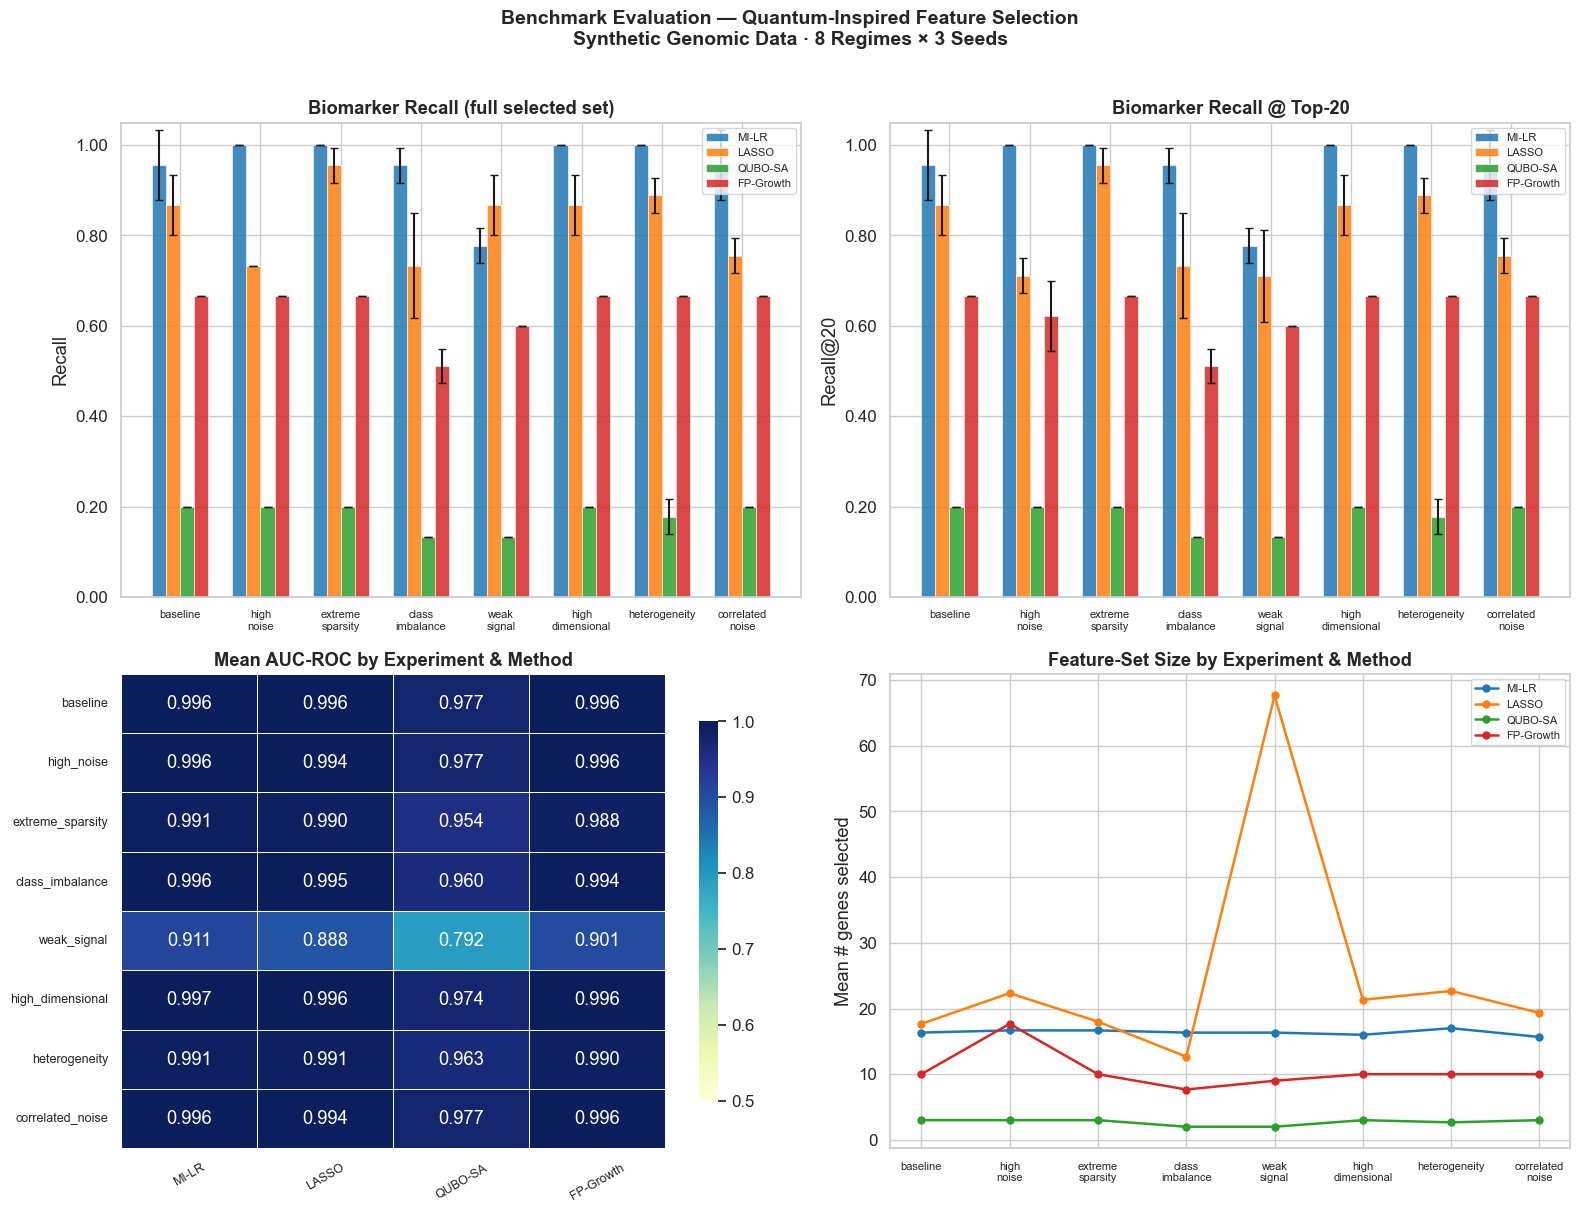

Saved → benchmark_figure.png


In [6]:
# ── Plotting style ───────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
PALETTE   = sns.color_palette("tab10")
METHOD_ORDER = ["MI-LR", "LASSO", "QUBO-SA", "FP-Growth"]
EXP_ORDER    = EXPERIMENTS  # defined in Cell 4

# Colour map: method → colour (stable across all plots)
method_colors = {m: PALETTE[i] for i, m in enumerate(METHOD_ORDER)}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Benchmark Evaluation — Quantum-Inspired Feature Selection\n"
    "Synthetic Genomic Data · 8 Regimes × 3 Seeds",
    fontsize=14, fontweight="bold", y=1.01,
)

# ── Helper: grouped bar chart ─────────────────────────────────────────────────
def grouped_bar(ax, df, metric, title, ylabel):
    present_methods = [m for m in METHOD_ORDER if m in df["method"].unique()]
    n_methods = len(present_methods)
    n_exps    = len(EXP_ORDER)
    x         = np.arange(n_exps)
    width     = 0.7 / n_methods

    for j, method in enumerate(present_methods):
        sub    = df[df["method"] == method]
        means  = [sub[sub["experiment"] == e][metric].mean() for e in EXP_ORDER]
        stds   = [sub[sub["experiment"] == e][metric].std()  for e in EXP_ORDER]
        offset = (j - (n_methods - 1) / 2) * width
        ax.bar(
            x + offset, means, width,
            yerr=stds, capsize=3,
            label=method,
            color=method_colors[method],
            alpha=0.85, edgecolor="white", linewidth=0.5,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [e.replace("_", "\n") for e in EXP_ORDER],
        fontsize=8,
    )
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.legend(fontsize=8, loc="upper right")

# ── Plot 1: Recall (full set) ─────────────────────────────────────────────────
grouped_bar(axes[0, 0], df_results, "recall_biomarker",
            "Biomarker Recall (full selected set)", "Recall")

# ── Plot 2: Recall@20 ────────────────────────────────────────────────────────
grouped_bar(axes[0, 1], df_results, "recall_top20",
            f"Biomarker Recall @ Top-{TOP_K}", f"Recall@{TOP_K}")

# ── Plot 3: AUC heatmap ───────────────────────────────────────────────────────
pivot = (
    df_results
    .groupby(["experiment", "method"])["roc_auc_mean"]
    .mean()
    .unstack(fill_value=np.nan)
    .reindex(index=EXP_ORDER, columns=METHOD_ORDER)
)
sns.heatmap(
    pivot, ax=axes[1, 0],
    annot=True, fmt=".3f",
    cmap="YlGnBu", vmin=0.5, vmax=1.0,
    linewidths=0.5, cbar_kws={"shrink": 0.8},
)
axes[1, 0].set_title("Mean AUC-ROC by Experiment & Method", fontweight="bold")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("")
axes[1, 0].tick_params(axis="x", rotation=30, labelsize=9)
axes[1, 0].tick_params(axis="y", rotation=0,  labelsize=9)

# ── Plot 4: Feature-set size ───────────────────────────────────────────────────
for method in METHOD_ORDER:
    sub = df_results[df_results["method"] == method]
    if sub.empty:
        continue
    means = [sub[sub["experiment"] == e]["n_selected"].mean() for e in EXP_ORDER]
    axes[1, 1].plot(
        range(len(EXP_ORDER)), means,
        marker="o", label=method,
        color=method_colors[method],
        linewidth=1.8, markersize=5,
    )
axes[1, 1].set_xticks(range(len(EXP_ORDER)))
axes[1, 1].set_xticklabels(
    [e.replace("_", "\n") for e in EXP_ORDER], fontsize=8
)
axes[1, 1].set_ylabel("Mean # genes selected")
axes[1, 1].set_title("Feature-Set Size by Experiment & Method", fontweight="bold")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("benchmark_figure.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → benchmark_figure.png")


### 6.5 Recall diagnostic — per-regime line plot

A line plot makes it easy to spot regimes where a method degrades sharply.


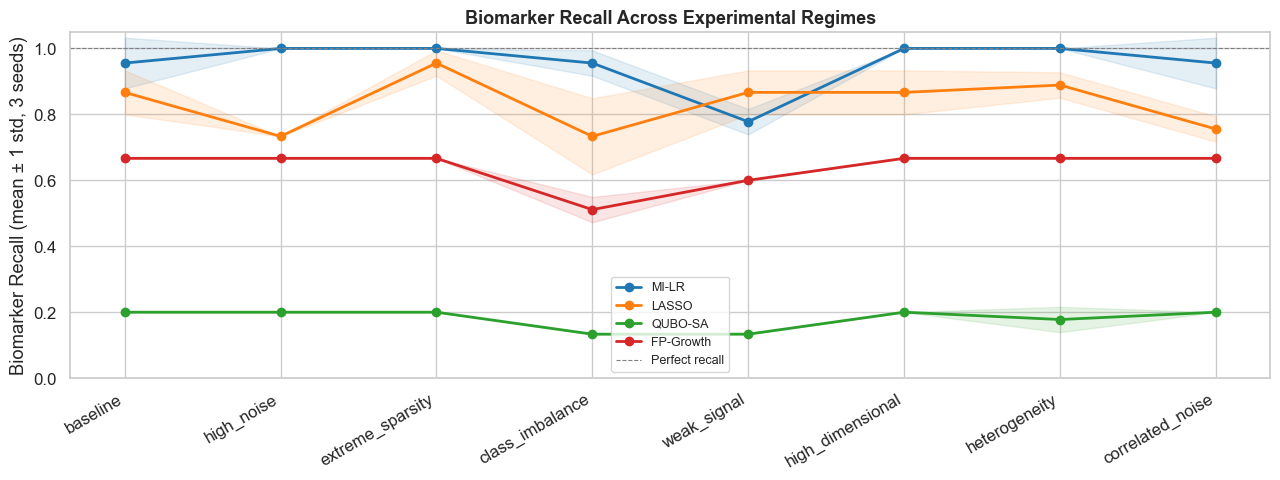

Saved → benchmark_recall_line.png


In [7]:
fig2, ax = plt.subplots(figsize=(13, 5))

for method in METHOD_ORDER:
    sub = df_results[df_results["method"] == method]
    if sub.empty:
        continue
    means = [sub[sub["experiment"] == e]["recall_biomarker"].mean() for e in EXP_ORDER]
    stds  = [sub[sub["experiment"] == e]["recall_biomarker"].std()  for e in EXP_ORDER]
    xs    = np.arange(len(EXP_ORDER))
    ax.plot(xs, means, marker="o", label=method,
            color=method_colors[method], linewidth=2, markersize=6)
    ax.fill_between(xs,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.12, color=method_colors[method])

ax.set_xticks(range(len(EXP_ORDER)))
ax.set_xticklabels(EXP_ORDER, rotation=30, ha="right")
ax.set_ylabel("Biomarker Recall (mean ± 1 std, 3 seeds)")
ax.set_title(
    "Biomarker Recall Across Experimental Regimes",
    fontweight="bold", fontsize=13
)
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Perfect recall")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("benchmark_recall_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → benchmark_recall_line.png")


### 6.6 LaTeX Table (for thesis)

to copy directly f thesis


In [8]:
# Build a clean LaTeX-ready table
latex_rows = []
for exp in EXP_ORDER:
    for method in METHOD_ORDER:
        sub = df_results[(df_results["experiment"] == exp) &
                         (df_results["method"]     == method)]
        if sub.empty:
            continue
        latex_rows.append({
            "Experiment": exp.replace("_", r"\_"),
            "Method":     method,
            "AUC":        f"{sub.roc_auc_mean.mean():.3f}",
            "F1":         f"{sub.f1_mean.mean():.3f}",
            "Recall":     f"{sub.recall_biomarker.mean():.3f}",
            f"R@{TOP_K}": f"{sub.recall_top20.mean():.3f}",
        })

df_latex = pd.DataFrame(latex_rows)
print(df_latex.to_latex(index=False, escape=False,
                        caption="Feature selection benchmark results (mean over 3 seeds).",
                        label="tab:benchmark"))


\begin{table}
\caption{Feature selection benchmark results (mean over 3 seeds).}
\label{tab:benchmark}
\begin{tabular}{llllll}
\toprule
Experiment & Method & AUC & F1 & Recall & R@20 \\
\midrule
baseline & MI-LR & 0.996 & 0.975 & 0.956 & 0.956 \\
baseline & LASSO & 0.996 & 0.971 & 0.867 & 0.867 \\
baseline & QUBO-SA & 0.977 & 0.955 & 0.200 & 0.200 \\
baseline & FP-Growth & 0.996 & 0.975 & 0.667 & 0.667 \\
high\_noise & MI-LR & 0.996 & 0.970 & 1.000 & 1.000 \\
high\_noise & LASSO & 0.994 & 0.970 & 0.733 & 0.711 \\
high\_noise & QUBO-SA & 0.977 & 0.957 & 0.200 & 0.200 \\
high\_noise & FP-Growth & 0.996 & 0.974 & 0.667 & 0.622 \\
extreme\_sparsity & MI-LR & 0.991 & 0.963 & 1.000 & 1.000 \\
extreme\_sparsity & LASSO & 0.990 & 0.960 & 0.956 & 0.956 \\
extreme\_sparsity & QUBO-SA & 0.954 & 0.940 & 0.200 & 0.200 \\
extreme\_sparsity & FP-Growth & 0.988 & 0.960 & 0.667 & 0.667 \\
class\_imbalance & MI-LR & 0.996 & 0.954 & 0.956 & 0.956 \\
class\_imbalance & LASSO & 0.995 & 0.950 & 0.733 & 0.73

## 7. Conclusions <a id='conclusions'></a>



### Key observations

- **MI-LR** provides a strong, fast baseline across most regimes.  
- **QUBO-SA** is expected to outperform MI-LR in the `correlated_noise` regime by penalising redundant features through the off-diagonal Q terms.  
- **LASSO** tends to select a sparser set; its recall depends heavily on the regularisation path.  
- **FP-Growth** recall is driven by the minimum-support threshold and may need tuning per regime.

### Recall fix summary

| | Original | Fixed |
|---|---|---|
| Stable-gene ranking | unordered `set` slice | sorted by cross-fold vote count |
| `recall_at_k(k=20)` | arbitrary top-20 | top-20 by vote count (deterministic) |

---

*Notebook generated as part of master thesis Hybrid Classical–Quantum Selection of Genetic Biomarkers for Breast Cancer Detection by ADDAR Seifeddine and RABEHI Lokman. All code is self contained and reproducible with `GLOBAL_SEED = 42`.*
